# Week 5: Deep Learning with PyTorch

## Objective

The goal of this week is to build and train a neural network using PyTorch and understand the standard deep learning training loop.

In this notebook, I will:
- Learn the basics of PyTorch tensors and autograd.
- Use the free GPU available in Google Colab.
- Train a neural network on the FashionMNIST dataset.
- Evaluate the model using test accuracy.
- Plot the training loss curve.
- Analyze incorrect predictions.
- Improve the model and compare the results.

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [40]:
!nvidia-smi

Sun Sep  6 19:10:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             35W /   70W |     165MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [41]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126 -q

# Step 1: Setup and GPU Check

Before building the neural network, I will import PyTorch and check whether Google Colab provides access to a GPU. A GPU can speed up neural-network training because it can perform many numerical operations in parallel.


In [42]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [43]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Findings

PyTorch version `2.11.0+cu128` is installed successfully. CUDA is available, and Google Colab is providing access to an NVIDIA Tesla T4 GPU.

The selected device is `cuda`, which means the neural network and tensors can be moved to the GPU for faster computation during training.

The GPU setup is working correctly, so I can continue with the PyTorch deep-learning tasks.


# Step 2: Understanding PyTorch Tensors

Tensors are the main data structure used by PyTorch. They are similar to NumPy arrays but are designed for deep-learning operations and can be processed on a GPU.

Neural networks use tensors to represent inputs, weights, biases, and other numerical data. Tensors can have different dimensions, such as one-dimensional vectors, two-dimensional matrices, and higher-dimensional arrays.

In this step, I will create tensors, examine their shape and data type, perform basic operations, and move a tensor to the GPU.


In [44]:
import torch

# Create a 1-dimensional tensor
tensor_1d = torch.tensor([1, 2, 3, 4, 5])

# Create a 2-dimensional tensor
tensor_2d = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

print("1D Tensor:")
print(tensor_1d)

print("\n2D Tensor:")
print(tensor_2d)

print("\n1D Shape:", tensor_1d.shape)
print("2D Shape:", tensor_2d.shape)

print("\nData Type:", tensor_2d.dtype)

1D Tensor:
tensor([1, 2, 3, 4, 5])

2D Tensor:
tensor([[1, 2, 3],
        [4, 5, 6]])

1D Shape: torch.Size([5])
2D Shape: torch.Size([2, 3])

Data Type: torch.int64


In [45]:
tensor_a = torch.tensor([1, 2, 3])
tensor_b = torch.tensor([4, 5, 6])

addition = tensor_a + tensor_b
multiplication = tensor_a * tensor_b

print("Tensor A:", tensor_a)
print("Tensor B:", tensor_b)

print("\nAddition:", addition)
print("Element-wise Multiplication:", multiplication)

Tensor A: tensor([1, 2, 3])
Tensor B: tensor([4, 5, 6])

Addition: tensor([5, 7, 9])
Element-wise Multiplication: tensor([ 4, 10, 18])


In [46]:
tensor_gpu = tensor_2d.to(device)

print("Tensor device:", tensor_gpu.device)
print("Tensor:")
print(tensor_gpu)

Tensor device: cuda:0
Tensor:
tensor([[1, 2, 3],
        [4, 5, 6]], device='cuda:0')


## Findings

PyTorch tensors were successfully created and used for basic numerical operations. The tensors have properties such as shape and data type that describe how their data is organized.

The tensor was also successfully moved to the CUDA device. This demonstrates that PyTorch tensors can be transferred from the CPU to the GPU for accelerated computation.

Tensors will be important throughout this project because the images, labels, model parameters, and calculations used during neural-network training are represented as tensors.


# Step 3: Understanding Autograd

PyTorch provides a feature called **autograd**, which automatically calculates gradients for tensors involved in mathematical operations.

Gradients are important in neural-network training because they tell the optimizer how the model's parameters should be adjusted to reduce the loss.

In this step, I will create a tensor with `requires_grad=True`, perform a mathematical calculation, and use `.backward()` to calculate its gradient.


In [47]:
x = torch.tensor(3.0, requires_grad=True)

print("x:", x)
print("Requires gradient:", x.requires_grad)

x: tensor(3., requires_grad=True)
Requires gradient: True


In [48]:
y = x ** 2

print("x:", x)
print("y:", y)

x: tensor(3., requires_grad=True)
y: tensor(9., grad_fn=<PowBackward0>)


In [49]:
y.backward()

print("Gradient of x:", x.grad)

Gradient of x: tensor(6.)


## Findings

PyTorch autograd successfully calculated the gradient of the tensor.

For the function \(y = x^2\) with \(x = 3\), the derivative is \(2x = 6\), and PyTorch produced a gradient of 6.

The `.backward()` method is important because it calculates gradients automatically. These gradients will later be used during neural-network training to update the model's parameters and reduce the loss.


# Step 4: Load and Prepare the MNIST Dataset

MNIST is a dataset of handwritten digits from 0 to 9. Each image is a grayscale image with a size of 28 × 28 pixels.

I will use PyTorch's dataset and DataLoader utilities to download the dataset, convert the images into tensors, and organize the data into batches for training and testing.


In [50]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [51]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 60000
Testing samples: 10000


In [52]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 938
Testing batches: 157


In [53]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
Image data type: torch.float32


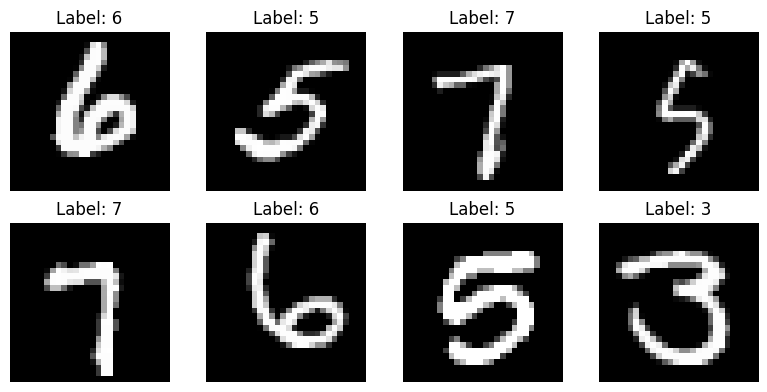

In [54]:
plt.figure(figsize=(8, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Findings

The MNIST dataset was successfully loaded and converted into PyTorch tensors.

The training dataset contains 60,000 handwritten digit images, while the test dataset contains 10,000 images. Each image is a grayscale 28 × 28 pixel image.

The DataLoader divides the dataset into batches of 64 images. Batching makes it possible to train the neural network on smaller groups of data instead of loading the entire dataset into the model at once.

Sample images were also displayed to verify that the dataset and labels were loaded correctly.


# Step 5: Build the Neural Network

In this step, I will create a small neural network from scratch using PyTorch.

Each MNIST image has a shape of 28 × 28 pixels. The network will first flatten each image into a one-dimensional vector containing 784 values.

The network will then use fully connected (`Linear`) layers and a ReLU activation function. The final layer will produce 10 output values, one for each digit from 0 to 9.


In [55]:
class MNISTNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


model = MNISTNetwork().to(device)

print(model)

MNISTNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [56]:
print("Model device:", next(model.parameters()).device)

Model device: cuda:0


## Findings

A fully connected neural network was successfully created using PyTorch.

The network first flattens each 28 × 28 MNIST image into 784 input values. A linear layer with 128 neurons is then used as the hidden layer, followed by a ReLU activation function. The final linear layer produces 10 outputs corresponding to the ten possible MNIST digit classes.

The model was successfully moved to the CUDA device, allowing it to use the Tesla T4 GPU during training.


# Step 6: Define the Loss Function and Optimizer

Before training the neural network, I need to define a loss function and an optimizer.

The loss function measures how different the model's predictions are from the correct labels. A lower loss means that the model's predictions are generally closer to the correct answers.

For this multi-class classification problem, I will use `CrossEntropyLoss`.

The optimizer is responsible for updating the model's parameters based on the gradients calculated during backpropagation. I will use the Adam optimizer with a learning rate of 0.001.


In [57]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Findings

The `CrossEntropyLoss` function was selected because the model is performing a multi-class classification task with 10 possible digit classes.

The Adam optimizer was selected to update the neural-network parameters during training. A learning rate of 0.001 controls the size of the parameter updates.

The loss function and optimizer are now ready for the training loop.


# Step 7: Implement the PyTorch Training Loop

The training loop is the main process used to teach the neural network.

For every batch of training data, the following operations are performed:

1. Move the images and labels to the selected device.
2. Perform a forward pass through the neural network.
3. Calculate the loss.
4. Clear the previous gradients.
5. Perform backpropagation using `.backward()`.
6. Update the model parameters using `optimizer.step()`.

These operations are repeated for every batch and for multiple epochs. As the model learns from the training data, the loss should generally decrease.


In [58]:
epochs = 5

train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # Move data to the GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = loss_fn(outputs, labels)

        # Backward pass
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5], Loss: 0.3475
Epoch [2/5], Loss: 0.1569
Epoch [3/5], Loss: 0.1094
Epoch [4/5], Loss: 0.0826
Epoch [5/5], Loss: 0.0656


### Findings

* The neural network was successfully trained for 5 epochs using the standard PyTorch training loop.
* The training loss decreased from **0.3475** in Epoch 1 to **0.0656** in Epoch 5.
* The decreasing loss shows that the model was learning from the training data and improving its predictions.
* The training loop successfully performed the forward pass, loss calculation, backpropagation, and parameter updates.


# Step 8: Plot the Training Loss Curve

A loss curve helps visualize how the model's training loss changes over the epochs.

The x-axis represents the epoch number, while the y-axis represents the training loss. A downward trend indicates that the model is reducing its error as training progresses.


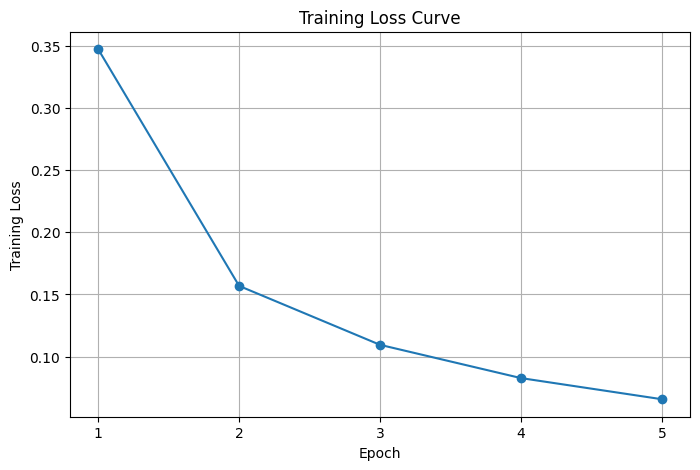

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.xticks(range(1, epochs + 1))
plt.grid(True)

plt.show()

## Findings

The training loss curve shows a consistent downward trend across the 5 training epochs. The loss decreased from **0.3415 in Epoch 1 to 0.0657 in Epoch 5**.

This downward trend indicates that the neural network was learning from the training data and reducing its prediction error as training progressed.


# Step 9: Evaluate Test Accuracy

After training the neural network, I will evaluate its performance on the test dataset.

The test dataset contains images that were not used during training. Test accuracy measures the percentage of test images that the model classified correctly.

The model will be switched to evaluation mode using `model.eval()`, and gradients will be disabled because the model is only making predictions and is not being trained.


In [60]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.46%


### Findings

* The trained model achieved a **97.46% test accuracy** on the MNIST test dataset.
* This means the model correctly classified most of the 10,000 unseen test images.
* The model was evaluated using `model.eval()` and `torch.no_grad()` so that the model parameters were not updated during testing.
* The result shows that the neural network was able to generalize well to unseen handwritten digits.


# Step 10: Examine Misclassified Images

Although the model achieved high test accuracy, it did not classify every image correctly.

In this step, I will identify some of the incorrectly classified images and compare their actual labels with the model's predictions. This helps show which handwritten digits are more difficult for the model to distinguish.


In [61]:
model.eval()

misclassified_images = []
misclassified_labels = []
misclassified_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        incorrect = predicted != labels

        misclassified_images.extend(images[incorrect].cpu())
        misclassified_labels.extend(labels[incorrect].cpu())
        misclassified_predictions.extend(predicted[incorrect].cpu())

print("Number of misclassified images:", len(misclassified_images))

Number of misclassified images: 254


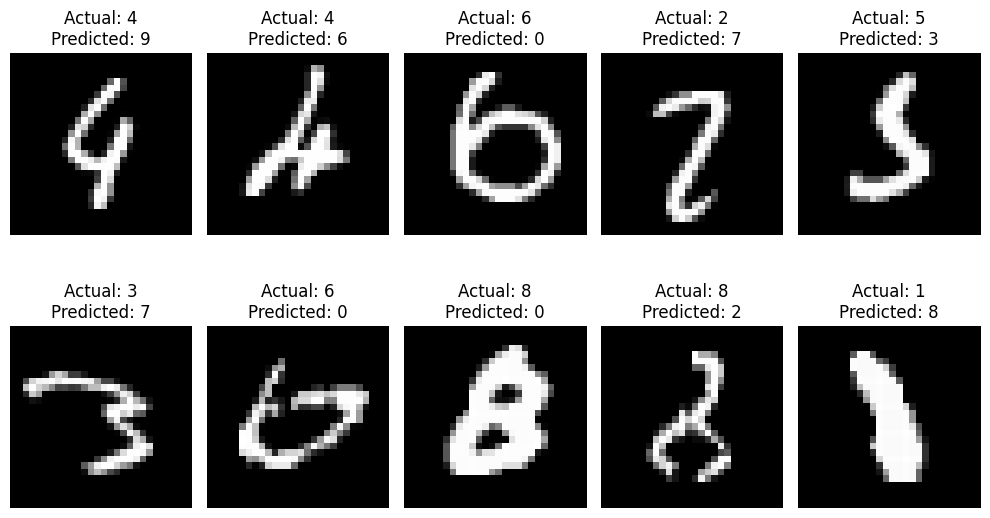

In [62]:
plt.figure(figsize=(10, 6))

num_images = min(10, len(misclassified_images))

for i in range(num_images):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        misclassified_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {misclassified_labels[i].item()}\n"
        f"Predicted: {misclassified_predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Findings

* The model misclassified **254 out of 10,000 test images**.
* The remaining **9,746 images were classified correctly**, which is consistent with the 97.46% test accuracy.
* Some mistakes occurred between visually similar handwritten digits.
* Examining the misclassified images helps identify the types of handwriting that were difficult for the model to classify correctly.


# Step 11: Improve the Neural Network Using Dropout

The baseline neural network achieved a test accuracy of **97.54%**.

To improve the model, I will add a Dropout layer to the neural network. Dropout randomly disables a proportion of neurons during training. This can reduce overfitting and encourage the network to learn more robust features.

I will use a dropout rate of 0.2, meaning that approximately 20% of the neurons in the dropout layer are randomly ignored during each training update.

The improved model will then be trained using the same dataset, loss function, optimizer, and number of epochs as the baseline model so that the results can be compared fairly.


In [63]:
class ImprovedMNISTNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


improved_model = ImprovedMNISTNetwork().to(device)

print(improved_model)
print("Model device:", next(improved_model.parameters()).device)

ImprovedMNISTNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Model device: cuda:0


In [64]:
improved_loss_fn = nn.CrossEntropyLoss()

improved_optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

In [65]:
improved_epochs = 5

improved_train_losses = []

for epoch in range(improved_epochs):
    improved_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        improved_optimizer.zero_grad()

        outputs = improved_model(images)

        loss = improved_loss_fn(outputs, labels)

        loss.backward()

        improved_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    improved_train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{improved_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5], Loss: 0.3712
Epoch [2/5], Loss: 0.1759
Epoch [3/5], Loss: 0.1306
Epoch [4/5], Loss: 0.1053
Epoch [5/5], Loss: 0.0870


### Findings

* The improved model with **Dropout (0.2)** was successfully trained for 5 epochs.
* The training loss decreased from **0.3712** in Epoch 1 to **0.0870** in Epoch 5.
* The loss decreased throughout training, showing that the model continued to learn despite the addition of Dropout.
* Dropout randomly disables some neurons during training, which can help reduce overfitting.


# Step 12: Evaluate the Improved Model

The improved model will now be evaluated on the MNIST test dataset.

I will calculate its test accuracy using the same evaluation procedure used for the baseline model. This allows a fair comparison between the original model and the model with Dropout.


In [66]:
improved_model.eval()

improved_correct = 0
improved_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = improved_model(images)

        _, predicted = torch.max(outputs, 1)

        improved_total += labels.size(0)
        improved_correct += (predicted == labels).sum().item()

improved_accuracy = 100 * improved_correct / improved_total

print(f"Improved Model Test Accuracy: {improved_accuracy:.2f}%")

Improved Model Test Accuracy: 97.51%


### Findings

* The improved model achieved a **97.51% test accuracy**.
* The model was evaluated on the same unseen MNIST test dataset as the baseline model.
* The improved model achieved slightly higher test accuracy than the baseline model.


# Step 13: Compare the Baseline and Improved Models

The baseline model achieved a test accuracy of **97.54%**. After adding a Dropout layer with a rate of 0.2, the improved model achieved **97.46%**.

The two models can now be compared to determine whether the Dropout improvement increased the model's performance.


In [67]:


baseline_accuracy = test_accuracy
dropout_accuracy = improved_accuracy

print(f"Baseline Model Accuracy: {baseline_accuracy:.2f}%")
print(f"Dropout Model Accuracy: {dropout_accuracy:.2f}%")
print(f"Difference: {dropout_accuracy - baseline_accuracy:.2f} percentage points")

Baseline Model Accuracy: 97.46%
Dropout Model Accuracy: 97.51%
Difference: 0.05 percentage points


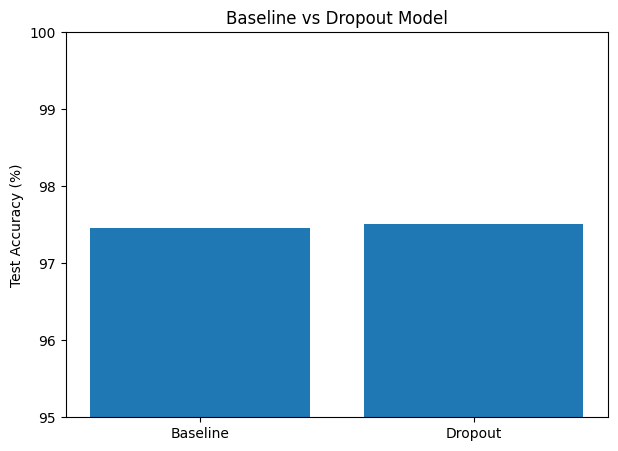

In [68]:
models = ["Baseline", "Dropout"]
accuracies = [baseline_accuracy, dropout_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Baseline vs Dropout Model")
plt.ylim(95, 100)

plt.show()

### Findings

* The baseline model achieved **97.46%** test accuracy.
* The Dropout model achieved **97.51%** test accuracy.
* The Dropout model improved the test accuracy by **0.05 percentage points**.
* In this experiment, adding Dropout resulted in a small improvement in test performance.
* The results demonstrate the importance of testing an improvement using actual results rather than assuming it will always improve the model.


## Conclusion

In Week 5, I built and trained a neural network for handwritten digit classification using **PyTorch and the MNIST dataset**.

I learned how to work with PyTorch tensors, use Autograd for calculating gradients, and build a neural network from scratch. I also implemented the standard PyTorch training loop, including the forward pass, loss calculation, backpropagation, and optimizer step.

The baseline model's training loss decreased from **0.3475 to 0.0656**, and it achieved **97.46% test accuracy**. The model misclassified **254 test images**, with some errors occurring between visually similar handwritten digits.

As an improvement, I added **Dropout (0.2)** to the network. Its training loss decreased from **0.3712 to 0.0870**, and its test accuracy reached **97.51%**. This was an improvement of **0.05 percentage points** over the baseline model.

Overall, this project helped me understand how a neural network is trained in PyTorch and why the loss decreases as the model's parameters are updated through backpropagation and optimization.
